<a href="https://colab.research.google.com/github/dinujakr/Final-year-project-IEKF-for-rigid-body-tracking/blob/main/Main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Simulation and experimental verification of a Intrinsic Extended Kalman filter for rigid body attitude tracking

#Linear Kalman Filter

Testing the linear kalman filter under smooth and rapid rotations using EuroC Datasets

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


###Load Data sets

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# ============================================================
# CHANGE THIS to switch between EuRoC MAV sequences
# Easy:   r"F:\Uni\FYP\ES7 3 exam\MH_01_easy"
# Medium: r"F:\Uni\FYP\ES7 3 example\MH_03_medium"
# Hard:   r"F:\Uni\FYP\ES7 3 example\MH_05_difficult"
# Very hard: r"F:\Uni\FYP\ES7 3 example\V2_03_difficult"

DATASET = "/content/drive/MyDrive/FYP/V2_03_difficult"
# ============================================================

imu_path = DATASET + r"/imu0/data.csv"
gt_path  = DATASET + r"/state_groundtruth_estimate0/data.csv"

# Load CSV
imu = pd.read_csv(imu_path)
gt  = pd.read_csv(gt_path)

In [4]:
t0 = min(imu.iloc[0,0], gt.iloc[0,0])   # same global reference

# IMU Timeline and raw values
t_imu = (imu.iloc[:,0].values - t0) * 1e-9
gyro = imu.iloc[:,1:4].values   # wx, wy, wz
acc  = imu.iloc[:,4:7].values   # ax, ay, az

# GT Timeline
t_gt  = (gt.iloc[:,0].values  - t0) * 1e-9

# Quaternion
q_gt = gt[[' q_RS_w []',' q_RS_x []',' q_RS_y []',' q_RS_z []']].values


# --- CONVERSION & UTILITY FUNCTIONS ---

# Convert accelerometer to Euler angles
def accel_to_euler(acc):
    ax, ay, az = acc
    norm = np.linalg.norm(acc)
    if norm == 0:
        return np.array([0.0, 0.0])
    ax, ay, az = ax/norm, ay/norm, az/norm

    phi = np.arctan2(ay, az)
    theta = np.arctan2(-ax, np.sqrt(ay**2 + az**2))

    return np.array([phi, theta])

# Convert Ground Truth Quaternions to Euler angles
def quat_to_euler(q):
    w, x, y, z = q
    phi = np.arctan2(2 * (w*x + y*z), 1 - 2 * (x*x + y*y))
    sin_pitch = np.clip(2 * (w*y - z*x), -1.0, 1.0)
    theta = np.arcsin(sin_pitch)
    psi = np.arctan2(2 * (w*z + x*y), 1 - 2 * (y*y + z*z))
    return np.array([phi, theta, psi])

# Properly unwrap cumulative angle trajectories to remove ±π wrap jumps
def unwrap_angle(a):
    a_unwrapped = np.copy(a)
    for i in range(1, len(a_unwrapped)):
        diff = a_unwrapped[i] - a_unwrapped[i-1]
        while diff > np.pi:
            a_unwrapped[i] -= 2 * np.pi
            diff -= 2 * np.pi
        while diff < -np.pi:
            a_unwrapped[i] += 2 * np.pi
            diff += 2 * np.pi
    return a_unwrapped


# --- DATA PROCESSING ---

# 1. Compute and unwrap direct sensor orientations from entire Accelerometer log
roll_meas = np.arctan2(acc[:, 1], acc[:, 2])
pitch_meas = np.arctan2(-acc[:, 0], np.sqrt(acc[:, 1]**2 + acc[:, 2]**2))

roll_meas = unwrap_angle(roll_meas)
pitch_meas = unwrap_angle(pitch_meas)

# 2. Extract full Ground Truth Euler angles from quaternions and unwrap them
euler_gt = np.array([quat_to_euler(q) for q in q_gt])
euler_gt[:, 0] = unwrap_angle(euler_gt[:, 0])
euler_gt[:, 1] = unwrap_angle(euler_gt[:, 1])

# 3. Interpolate Ground Truth data perfectly over the IMU sensor timeline
interp_gt_roll  = interp1d(t_gt, euler_gt[:, 0], bounds_error=False, fill_value='extrapolate')
interp_gt_pitch = interp1d(t_gt, euler_gt[:, 1], bounds_error=False, fill_value='extrapolate')

gt_roll_unwrapped  = interp_gt_roll(t_imu)
gt_pitch_unwrapped = interp_gt_pitch(t_imu)

dataset_name = DATASET.split("/")[-1]




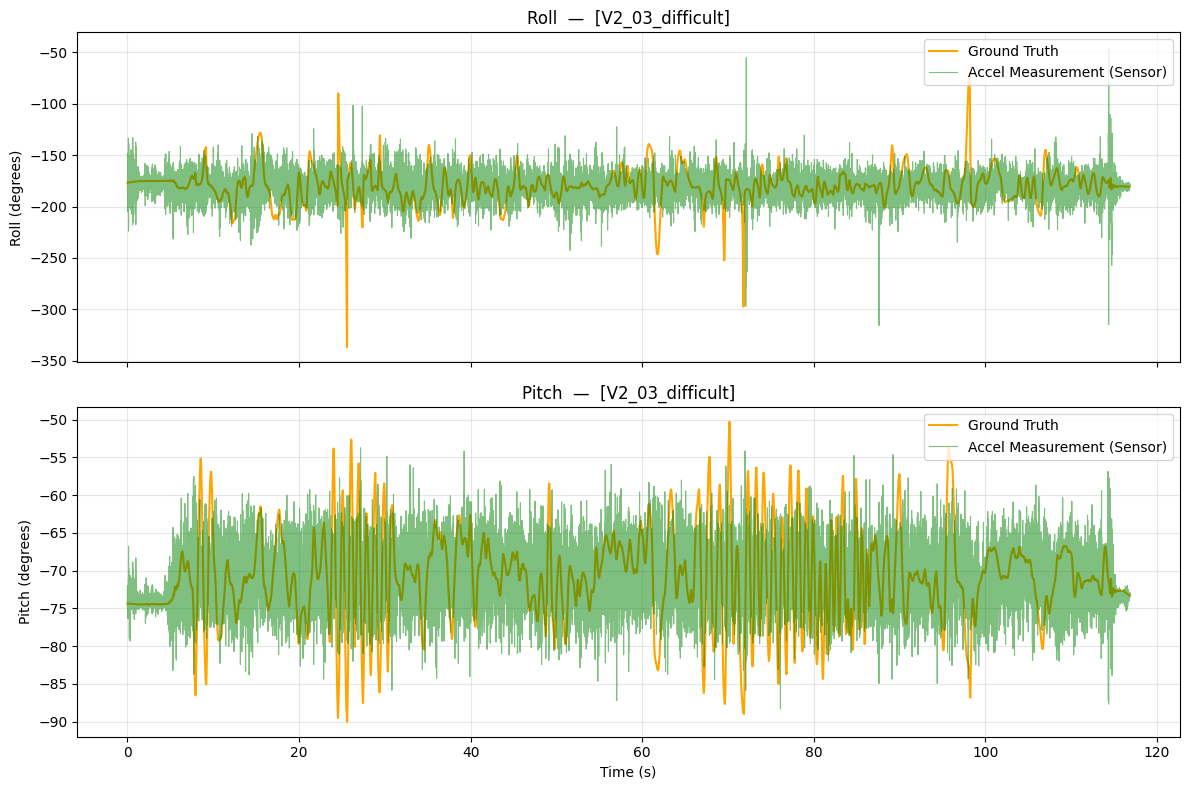

In [5]:
# --- PLOTTING DATA ---

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# --- Roll subplot ---
ax1.plot(t_imu, np.degrees(gt_roll_unwrapped), label='Ground Truth', color='orange', linewidth=1.5)
ax1.plot(t_imu, np.degrees(roll_meas), label='Accel Measurement (Sensor)', color='green', alpha=0.5, linewidth=0.8)
ax1.set_ylabel("Roll (degrees)")
ax1.set_title(f"Roll  —  [{dataset_name}]")
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

# --- Pitch subplot ---
ax2.plot(t_imu, np.degrees(gt_pitch_unwrapped), label='Ground Truth', color='orange', linewidth=1.5)
ax2.plot(t_imu, np.degrees(pitch_meas), label='Accel Measurement (Sensor)', color='green', alpha=0.5, linewidth=0.8)
ax2.set_xlabel("Time (s)")
ax2.set_ylabel("Pitch (degrees)")
ax2.set_title(f"Pitch  —  [{dataset_name}]")
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

###Linear system assumption and state estimation by linear kalman filter

$$
\mathbf{x} = \begin{bmatrix} \phi \\ \theta \\ \psi \end{bmatrix}
$$



=== RMSE Report [/content/drive/MyDrive/FYP/V2_03_difficult] ===
  Roll  RMSE : 16.811 degrees
  Pitch RMSE : 6.579 degrees
  Yaw   RMSE : 119.570 degrees



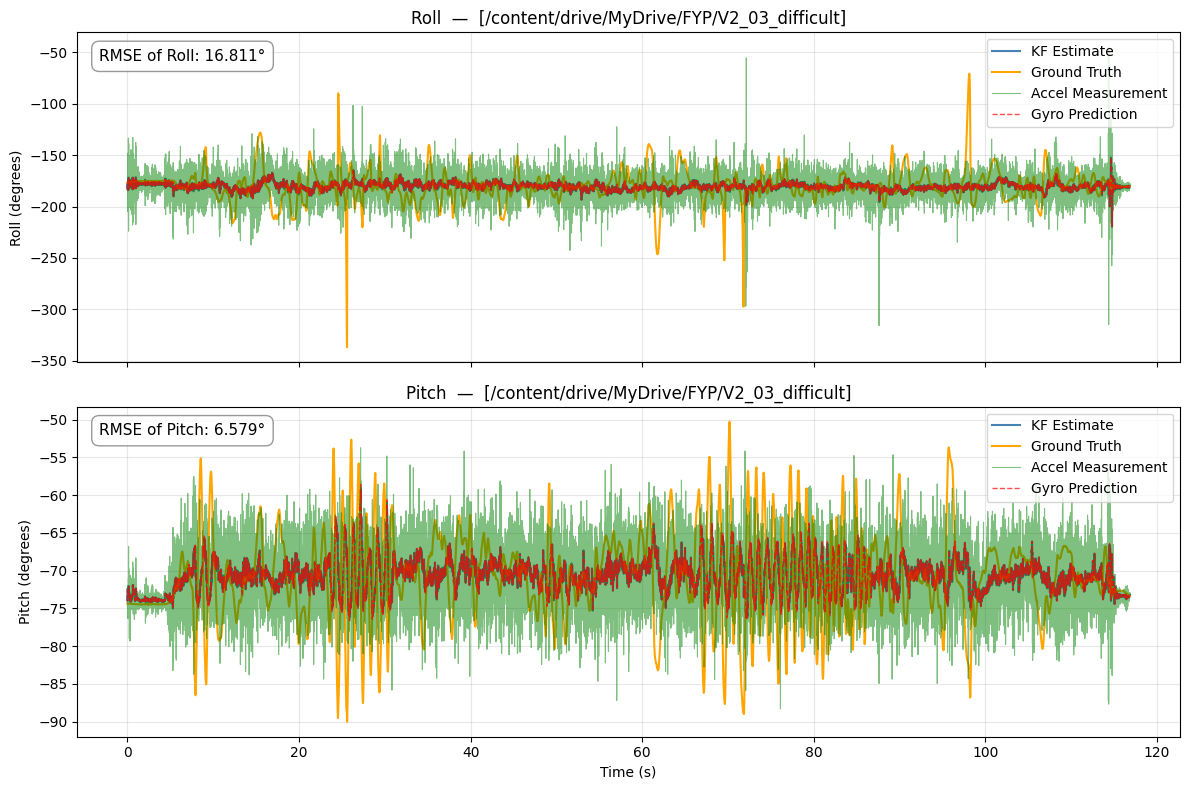

In [6]:
# IMU
t_imu = (imu.iloc[:,0].values - t0) * 1e-9
gyro = imu.iloc[:,1:4].values   # wx, wy, wz
acc  = imu.iloc[:,4:7].values   # ax, ay, az


# Initialize from first accel measurement
phi0, theta0 = accel_to_euler(acc[0])
x = np.array([phi0, theta0, 0.0])  # [roll, pitch, yaw]

P = np.eye(3) * 0.1

Q = np.eye(3) * 1e-4    # gyro integrates cleanly for short time
R = np.eye(2) * 1e-2    # accel-to-euler is moderately noisy


# Observation matrix
H = np.array([
    [1,0,0],
    [0,1,0]
])

x_est = []
x_pred_list = []   # gyro-only prediction (before KF update)
time_kf = []

for k in range(len(t_imu)-1):

    dt = t_imu[k+1] - t_imu[k]

    wx, wy, wz = gyro[k]

    # 🔹 Prediction (gyro integration only)
    x = x + np.array([wx, wy, wz]) * dt
    P = P + Q                            # covariance grows with process noise
    x_pred_list.append(x.copy())         # save before update

    # 🔹 Measurement (from accel)
    z = accel_to_euler(acc[k])
    z[0] = z[0]
    z[1] = z[1]

    # 🔹 Update
    y = z - H @ x
    y[0] = (y[0] + np.pi) % (2*np.pi) - np.pi   # wrap innovation to [-π, π]
    y[1] = (y[1] + np.pi) % (2*np.pi) - np.pi

    S = H @ P @ H.T + R
    K = P @ H.T @ np.linalg.inv(S)

    x = x + K @ y
    x[0] = x[0]
    x[1] = x[1]
    x[2] = x[2]

    P = (np.eye(3) - K @ H) @ P

    x_est.append(x.copy())
    time_kf.append(t_imu[k])

x_est = np.array(x_est)

#take above z values and plot
z1 = np.arctan2(acc[:,1], acc[:,2])
z2 = np.arctan2(-acc[:,0], np.sqrt(acc[:,1]**2 + acc[:,2]**2))

def quat_to_euler(q):
    w,x,y,z = q

    phi = np.arctan2(2*(w*x + y*z), 1 - 2*(x*x + y*y))
    sin_pitch = np.clip(2*(w*y - z*x), -1.0, 1.0)   # clamp to avoid NaN
    theta = np.arcsin(sin_pitch)
    psi = np.arctan2(2*(w*z + x*y), 1 - 2*(y*y + z*z))

    return np.array([phi, theta, psi])

#unwrap euler angles

def unwrap_angle(a):
    for i in range(1, len(a)):
        diff = a[i] - a[i-1]
        while diff > np.pi:
            a[i] -= 2*np.pi
            diff -= 2*np.pi
        while diff < -np.pi:
            a[i] += 2*np.pi
            diff += 2*np.pi
    return a


euler_gt = np.array([quat_to_euler(q) for q in q_gt])

#unwrap euler angles
euler_gt[:,0] = unwrap_angle(euler_gt[:,0])
euler_gt[:,1] = unwrap_angle(euler_gt[:,1])
euler_gt[:,2] = unwrap_angle(euler_gt[:,2])

roll_meas = np.arctan2(acc[:-1,1], acc[:-1,2])  # match EKF length
roll_meas = unwrap_angle(roll_meas)               # remove -π/+π wrapping spikes
dataset_name = DATASET.split("\\")[-1]

# Interpolate GT to KF timestamps for fair comparison
from scipy.interpolate import interp1d

time_kf = np.array(time_kf)

def compute_rmse(kf_col, gt_col):
    interp_gt = interp1d(t_gt, gt_col, bounds_error=False, fill_value='extrapolate')
    gt_at_kf  = interp_gt(time_kf)
    diff = kf_col - gt_at_kf
    # wrap angle difference to [-π, π]
    diff = (diff + np.pi) % (2*np.pi) - np.pi
    return np.sqrt(np.mean(diff**2))

rmse_roll  = compute_rmse(x_est[:,0], euler_gt[:,0])
rmse_pitch = compute_rmse(x_est[:,1], euler_gt[:,1])
rmse_yaw   = compute_rmse(x_est[:,2], euler_gt[:,2])

print(f"\n=== RMSE Report [{dataset_name}] ===")
print(f"  Roll  RMSE : {np.degrees(rmse_roll):.3f} degrees")
print(f"  Pitch RMSE : {np.degrees(rmse_pitch):.3f} degrees")
print(f"  Yaw   RMSE : {np.degrees(rmse_yaw):.3f} degrees")
print(f"==========================================\n")

x_pred_arr = np.array(x_pred_list)
# Unwrap estimates and predictions to remove wrap spikes in the plot
x_est[:,0] = unwrap_angle(x_est[:,0])
x_est[:,1] = unwrap_angle(x_est[:,1])
x_est[:,2] = unwrap_angle(x_est[:,2])

x_pred_arr[:,0] = unwrap_angle(x_pred_arr[:,0])
x_pred_arr[:,1] = unwrap_angle(x_pred_arr[:,1])
x_pred_arr[:,2] = unwrap_angle(x_pred_arr[:,2])

# Accelerometer-derived pitch measurement (match KF length)
pitch_meas = np.arctan2(-acc[:-1,0], np.sqrt(acc[:-1,1]**2 + acc[:-1,2]**2))
pitch_meas = unwrap_angle(pitch_meas)
pitch_meas = pitch_meas[:len(time_kf)]

# Interpolate GT to KF timestamps for overlay
interp_gt_roll  = interp1d(t_gt, euler_gt[:, 0], bounds_error=False, fill_value='extrapolate')
interp_gt_pitch = interp1d(t_gt, euler_gt[:, 1], bounds_error=False, fill_value='extrapolate')
gt_roll_at_kf   = interp_gt_roll(time_kf)
gt_pitch_at_kf  = interp_gt_pitch(time_kf)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# --- Roll subplot ---
ax1.plot(time_kf, np.degrees(x_est[:, 0]),       label='KF Estimate',       color='steelblue', linewidth=1.5)
ax1.plot(time_kf, np.degrees(gt_roll_at_kf),     label='Ground Truth',      color='orange',    linewidth=1.5)
ax1.plot(time_kf, np.degrees(roll_meas),          label='Accel Measurement', color='green',     alpha=0.5, linewidth=0.8)
ax1.plot(time_kf, np.degrees(x_pred_arr[:, 0]),   label='Gyro Prediction',   color='red',       linestyle='--', alpha=0.7, linewidth=1)
ax1.set_ylabel("Roll (degrees)")
ax1.set_title(f"Roll  —  [{dataset_name}]")
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

# Print RMSE in the figure
ax1.text(0.02, 0.95, f"RMSE of Roll: {np.degrees(rmse_roll):.3f}°",
         transform=ax1.transAxes, fontsize=11, verticalalignment='top',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='gray', alpha=0.8))

# --- Pitch subplot ---
ax2.plot(time_kf, np.degrees(x_est[:, 1]),       label='KF Estimate',       color='steelblue', linewidth=1.5)
ax2.plot(time_kf, np.degrees(gt_pitch_at_kf),    label='Ground Truth',      color='orange',    linewidth=1.5)
ax2.plot(time_kf, np.degrees(pitch_meas),         label='Accel Measurement', color='green',     alpha=0.5, linewidth=0.8)
ax2.plot(time_kf, np.degrees(x_pred_arr[:, 1]),   label='Gyro Prediction',   color='red',       linestyle='--', alpha=0.7, linewidth=1)
ax2.set_xlabel("Time (s)")
ax2.set_ylabel("Pitch (degrees)")
ax2.set_title(f"Pitch  —  [{dataset_name}]")
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)

# Print RMSE in the figure
ax2.text(0.02, 0.95, f"RMSE of Pitch: {np.degrees(rmse_pitch):.3f}°",
         transform=ax2.transAxes, fontsize=11, verticalalignment='top',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='gray', alpha=0.8))

plt.tight_layout()
plt.show()

###Non linear system


=== RMSE Report [/content/drive/MyDrive/FYP/V2_03_difficult] ===
  Roll  RMSE : 16.325 degrees
  Pitch RMSE : 5.818 degrees
  Yaw   RMSE : 102.162 degrees



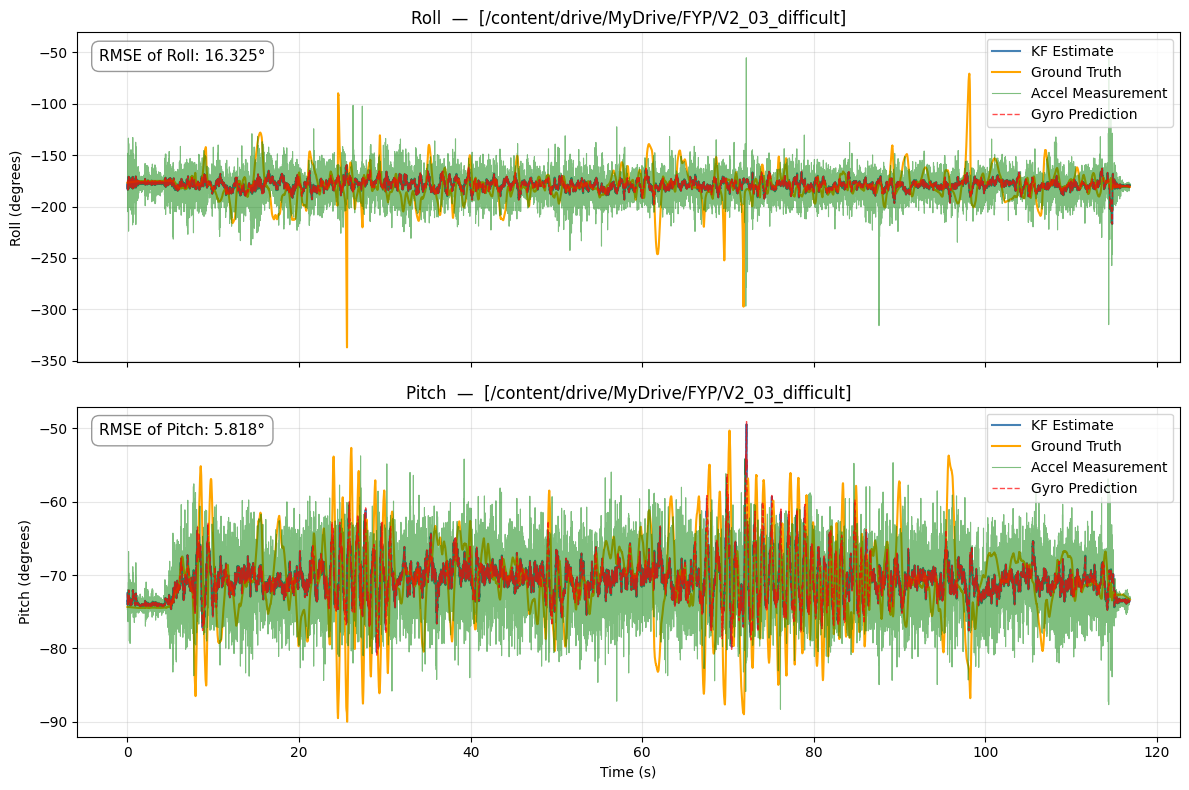

In [7]:

# Initialize from first accel measurement
phi0, theta0 = accel_to_euler(acc[0])
x = np.array([phi0, theta0, 0.0])  # [roll, pitch, yaw]

P = np.eye(3) * 0.1

Q = np.eye(3) * 1e-4   # gyro integrates cleanly for short time
R = np.eye(2) * 1e-2    # accel-to-euler is moderately noisy


# Observation matrix
H = np.array([
    [1,0,0],
    [0,1,0]
])

x_est = []
x_pred_list = []   # gyro-only prediction (before KF update)
time_kf = []

for k in range(len(t_imu)-1):

    dt = t_imu[k+1] - t_imu[k]

    wx, wy, wz = gyro[k]

    # 🔹 Prediction (gyro integration only)
    phi, theta, psi = x
    wx, wy, wz = gyro[k]

    # --- SAFE ANGLE HANDLING ---
    theta_safe = np.clip(theta, -np.pi/2 + 0.1, np.pi/2 - 0.1)

    tan_theta = np.tan(theta_safe)
    cos_theta = np.cos(theta_safe)
    cos_theta = np.clip(cos_theta, 1e-3, None)

    # --- EULER KINEMATICS ---
    phi_dot = wx + np.sin(phi)*tan_theta*wy + np.cos(phi)*tan_theta*wz
    theta_dot = np.cos(phi)*wy - np.sin(phi)*wz
    psi_dot = (np.sin(phi)/cos_theta)*wy + (np.cos(phi)/cos_theta)*wz

    # --- OPTIONAL SAFETY CLAMP (recommended) ---
    phi_dot   = np.clip(phi_dot,   -20, 20)
    theta_dot = np.clip(theta_dot, -20, 20)
    psi_dot   = np.clip(psi_dot,   -20, 20)

    # --- STATE UPDATE ---
    x = x + np.array([phi_dot, theta_dot, psi_dot]) * dt

    def wrap(a):
        return (a + np.pi) % (2*np.pi) - np.pi

    x[0] = wrap(x[0])
    x[1] = wrap(x[1])
    x[2] = wrap(x[2])

    F = np.eye(3)

    F[0,1] = (np.cos(phi)*np.tan(theta)*wy - np.sin(phi)*np.tan(theta)*wz) * dt
    F[1,0] = (-np.sin(phi)*wy - np.cos(phi)*wz) * dt
    P = F @ P @ F.T + Q                  # covariance grows with process noise
    x_pred_list.append(x.copy())         # save before update

    # 🔹 Measurement (from accel)
    g = 9.81
    a_norm = np.linalg.norm(acc[k])

    if abs(a_norm - g) < 1.0:   # threshold (tune 0.5–2.0)
        use_acc = True
    else:
        use_acc = False

    # 🔹 Update
    if use_acc:
        z = accel_to_euler(acc[k])

        y = z - H @ x
        y[0] = wrap(y[0])
        y[1] = wrap(y[1])

        S = H @ P @ H.T + R
        K = P @ H.T @ np.linalg.inv(S)

        x = x + K @ y
        P = (np.eye(3) - K @ H) @ P

    x_est.append(x.copy())
    time_kf.append(t_imu[k])

x_est = np.array(x_est)

#take above z values and plot
z1 = np.arctan2(acc[:,1], acc[:,2])
z2 = np.arctan2(-acc[:,0], np.sqrt(acc[:,1]**2 + acc[:,2]**2))

def quat_to_euler(q):
    w,x,y,z = q

    phi = np.arctan2(2*(w*x + y*z), 1 - 2*(x*x + y*y))
    sin_pitch = np.clip(2*(w*y - z*x), -1.0, 1.0)   # clamp to avoid NaN
    theta = np.arcsin(sin_pitch)
    psi = np.arctan2(2*(w*z + x*y), 1 - 2*(y*y + z*z))

    return np.array([phi, theta, psi])

#unwrap euler angles

def unwrap_angle(a):
    for i in range(1, len(a)):
        diff = a[i] - a[i-1]
        while diff > np.pi:
            a[i] -= 2*np.pi
            diff -= 2*np.pi
        while diff < -np.pi:
            a[i] += 2*np.pi
            diff += 2*np.pi
    return a


euler_gt = np.array([quat_to_euler(q) for q in q_gt])

#unwrap euler angles
euler_gt[:,0] = unwrap_angle(euler_gt[:,0])
euler_gt[:,1] = unwrap_angle(euler_gt[:,1])
euler_gt[:,2] = unwrap_angle(euler_gt[:,2])

roll_meas = np.arctan2(acc[:-1,1], acc[:-1,2])
roll_meas = unwrap_angle(roll_meas)
roll_meas = roll_meas[:len(time_kf)]
dataset_name = DATASET.split("\\")[-1]

# Interpolate GT to KF timestamps for fair comparison
from scipy.interpolate import interp1d

time_kf = np.array(time_kf)

def compute_rmse(kf_col, gt_col):
    interp_gt = interp1d(t_gt, gt_col, bounds_error=False, fill_value='extrapolate')
    gt_at_kf  = interp_gt(time_kf)
    diff = kf_col - gt_at_kf
    # wrap angle difference to [-π, π]
    diff = (diff + np.pi) % (2*np.pi) - np.pi
    return np.sqrt(np.mean(diff**2))

rmse_roll  = compute_rmse(x_est[:,0], euler_gt[:,0])
rmse_pitch = compute_rmse(x_est[:,1], euler_gt[:,1])
rmse_yaw   = compute_rmse(x_est[:,2], euler_gt[:,2])

print(f"\n=== RMSE Report [{dataset_name}] ===")
print(f"  Roll  RMSE : {np.degrees(rmse_roll):.3f} degrees")
print(f"  Pitch RMSE : {np.degrees(rmse_pitch):.3f} degrees")
print(f"  Yaw   RMSE : {np.degrees(rmse_yaw):.3f} degrees")
print(f"==========================================\n")

x_pred_arr = np.array(x_pred_list)

# Unwrap estimates and predictions to remove wrap spikes in the plot
x_est[:,0] = unwrap_angle(x_est[:,0])
x_est[:,1] = unwrap_angle(x_est[:,1])
x_est[:,2] = unwrap_angle(x_est[:,2])

x_pred_arr[:,0] = unwrap_angle(x_pred_arr[:,0])
x_pred_arr[:,1] = unwrap_angle(x_pred_arr[:,1])
x_pred_arr[:,2] = unwrap_angle(x_pred_arr[:,2])

# Accelerometer-derived pitch measurement (match KF length)
pitch_meas = np.arctan2(-acc[:-1,0], np.sqrt(acc[:-1,1]**2 + acc[:-1,2]**2))
pitch_meas = unwrap_angle(pitch_meas)
pitch_meas = pitch_meas[:len(time_kf)]

# Interpolate GT to KF timestamps for overlay
interp_gt_roll  = interp1d(t_gt, euler_gt[:, 0], bounds_error=False, fill_value='extrapolate')
interp_gt_pitch = interp1d(t_gt, euler_gt[:, 1], bounds_error=False, fill_value='extrapolate')
gt_roll_at_kf   = interp_gt_roll(time_kf)
gt_pitch_at_kf  = interp_gt_pitch(time_kf)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# --- Roll subplot ---
ax1.plot(time_kf, np.degrees(x_est[:, 0]),       label='KF Estimate',       color='steelblue', linewidth=1.5)
ax1.plot(time_kf, np.degrees(gt_roll_at_kf),     label='Ground Truth',      color='orange',    linewidth=1.5)
ax1.plot(time_kf, np.degrees(roll_meas),          label='Accel Measurement', color='green',     alpha=0.5, linewidth=0.8)
ax1.plot(time_kf, np.degrees(x_pred_arr[:, 0]),   label='Gyro Prediction',   color='red',       linestyle='--', alpha=0.7, linewidth=1)
ax1.set_ylabel("Roll (degrees)")
ax1.set_title(f"Roll  —  [{dataset_name}]")
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

# Print RMSE in the figure
ax1.text(0.02, 0.95, f"RMSE of Roll: {np.degrees(rmse_roll):.3f}°",
         transform=ax1.transAxes, fontsize=11, verticalalignment='top',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='gray', alpha=0.8))

# --- Pitch subplot ---
ax2.plot(time_kf, np.degrees(x_est[:, 1]),       label='KF Estimate',       color='steelblue', linewidth=1.5)
ax2.plot(time_kf, np.degrees(gt_pitch_at_kf),    label='Ground Truth',      color='orange',    linewidth=1.5)
ax2.plot(time_kf, np.degrees(pitch_meas),         label='Accel Measurement', color='green',     alpha=0.5, linewidth=0.8)
ax2.plot(time_kf, np.degrees(x_pred_arr[:, 1]),   label='Gyro Prediction',   color='red',       linestyle='--', alpha=0.7, linewidth=1)
ax2.set_xlabel("Time (s)")
ax2.set_ylabel("Pitch (degrees)")
ax2.set_title(f"Pitch  —  [{dataset_name}]")
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)

# Print RMSE in the figure
ax2.text(0.02, 0.95, f"RMSE of Pitch: {np.degrees(rmse_pitch):.3f}°",
         transform=ax2.transAxes, fontsize=11, verticalalignment='top',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='gray', alpha=0.8))

plt.tight_layout()
plt.show()